### Chargement et Prétraitement du Dataset

**Importer les bibliothèques nécessaires**


In [7]:
import os
import cv2
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
# from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split

**Charger les images du dataset et vérifier leurs extensions (jpeg, jpg, bmp, png). Supprimer celles qui ne correspondent pas**

In [5]:
data_original='../data/raw/Data'
labels=list()
images=list()
extensions=("jpeg", "jpg", "bmp", "png")


for dossier in os.listdir(data_original) :
    dossier_path=os.path.join(data_original,dossier)
    if os.path.isdir(dossier_path):
        for img in os.listdir(dossier_path):
            img_path= os.path.join(dossier_path,img)
            if not img.lower().endswith(extensions):
                print(f"Fichier supprimé (extension invalide) : {img}")
                os.remove(img_path)
                continue
            try:
                img=cv2.imread(img_path)
                img=cv2.resize(img,(244,244))
                images.append(img)
                labels.append(dossier)
            except:
                print(f"Erreur avec l'image: {img}")
            

 **Convertir les listes images et étiquettes en tableaux NumPy pour les rendre exploitables par le modèle CNN**


In [11]:
x=np.array(images,dtype="float32")
y=np.array(labels)

**Afficher graphiquement le nombre d’images dans chaque classe**

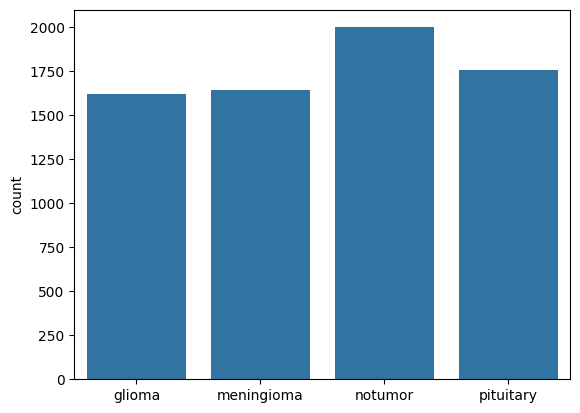

In [13]:
sns.countplot(x=y)
plt.show()


**Montrer un échantillon d’images par classe**

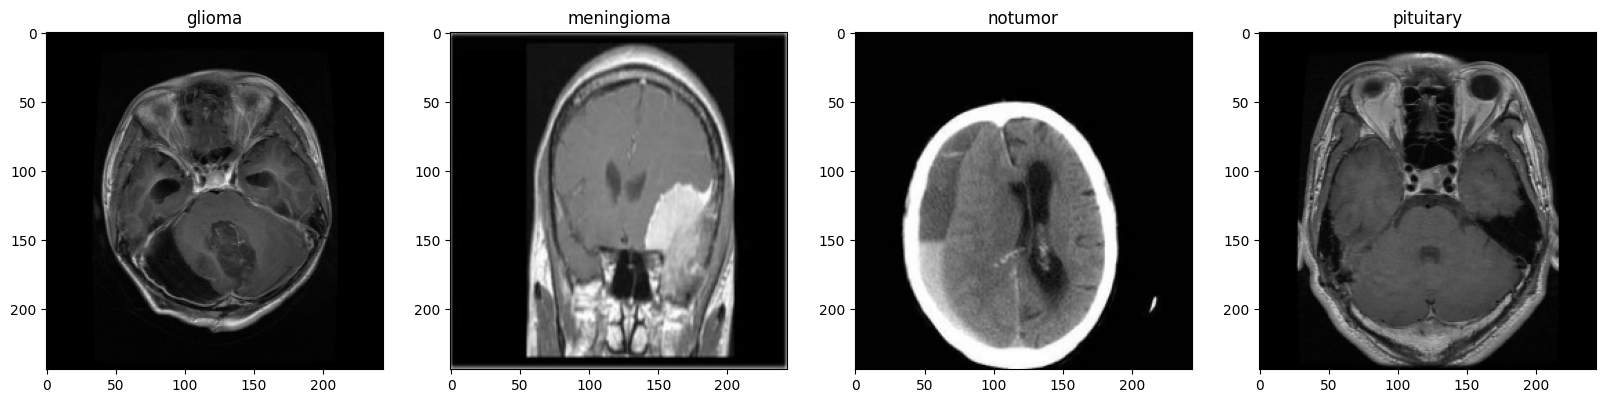

In [16]:
classes_name=np.unique(labels)
plt.figure(figsize=(20,15))
for i,classe in enumerate(classes_name):
    idx=labels.index(classe)
    plt.subplot(1,len(classes_name),i+1)
    plt.imshow(cv2.cvtColor(images[idx],cv2.COLOR_BGR2RGB))
    plt.title(classe)
    
plt.show()
